# 0: Setup

In [1]:
print("Starting pipeline.")

### Set the date, start the timer
import time
# date = time.strftime('%d%b%y', time.localtime())
date = "07Jul26_test2"

def timestamp():
    return(f"[{time.strftime("%H:%M:%S", time.localtime())}]")

def timer(start_time, return_tuple = False):
    elapsed_time = time.time() - start_time

    hours = elapsed_time//3600
    minutes = (elapsed_time//60)%60
    seconds = elapsed_time - 3600 * hours - 60 * minutes
    
    if return_tuple:
        return (hours, minutes, seconds)
    
    if hours > 0:
        return f'{hours:.0f}h {minutes:.0f}m {seconds:.1f}s'
    
    if minutes > 0:
        return f'{minutes:.0f}m {seconds:.1f}s'
    
    return f'{seconds:.1f}s'

start_time = time.time()

print(timestamp(), "Started timer. Importing modules", end = "\r")

### System imports
import sys, os, shutil
import glob

### I/O imports
import h5py
import tables_io
import pandas as pd

### Operations
import numpy as np

### RAIL imports
from rail.core.data import DataStore, PqHandle, ModelHandle
from rail.core.stage import RailStage

from MultiSurveyErrorModel import MultiSurveyErrorModel
from UMAPEstimator import UMAPEstimator

print(timestamp(), "Finished importing modules. Time elapsed: ", timer(start_time))

### Initialize random state
seed = 42
rng = np.random.default_rng(seed = seed)

### Specify outputs directory
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/{date}"
os.makedirs(outputs_directory, exist_ok = True)
    

Starting pipeline.
[17:34:20] Finished importing modules. Time elapsed:  25.9s


# 1: Create datasets

In [21]:
print(timestamp(), "Creating datasets.")

### Specify path to noiseless catalog and redshifts
noiseless_catalog_filepath = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26.pq"
redshifts_filepath = "/pscratch/sd/s/sajkov/data/mock_catalog_Ch1_26.h5"

DATASET_popCosmos_full   = tables_io.read(noiseless_catalog_filepath)
with h5py.File(redshifts_filepath) as simulated_catalog:
    REDSHIFTS_popCosmos_full = simulated_catalog['sps_parameters'][:, -1]

### Number of pop-cosmos sources to use in analysis
training_cut   = 100 ### Number of sources used to train the estimators
estimation_cut = 1_000   ### Number of sources for which to estimate redshifts

### Randomize full dataset indices
len_DATASET_popCosmos_full = len(DATASET_popCosmos_full)
RANDIDX_popCosmos_full = rng.choice(np.arange(len_DATASET_popCosmos_full),
                                    len_DATASET_popCosmos_full,
                                    replace = False)

RANDIDX_DeepField_full,\
    RANDIDX_DeepField_lpReference_full,\
        RANDIDX_WideFastDeep_full = np.array_split(RANDIDX_popCosmos_full, 3)

### 5-sigma limiting depths ------------------
### LSST: median values for COSMOS deep field from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Roman from https://github.com/jfcrenshaw/photerr/blob/a014b39729ddde3daf80be2dbe82f5a7f958882c/photerr/roman.py#L120-L126
### HSC Niji (60 min exposure) from https://sites.google.com/view/hsc-mb-survey3/filter-specification?authuser=0 
###
### Acessed June 3, 2026
### --------------------------------------------

M5_DEPTHS_DeepField = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                      'Roman_F062': 27.7,
                      'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}

iBandLimit_DeepField = 27

### 5-sigma limiting depths for WideFastDeep from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Column `DD:WFD CoaddM5`
M5_DEPTHS_WideFastDeep = {'LSST_u'    : 25.61,
                          'LSST_g'    : 26.90,
                          'LSST_r'    : 26.87,
                          'LSST_i'    : 26.43,
                          'LSST_z'    : 25.73,
                          'LSST_y'    : 24.79}

iBandLimit_WideFastDeep = 25

### Get list of bands
BANDS_DeepField = list(M5_DEPTHS_DeepField.keys())
ERR_BANDS_DeepField = [f"{key}_err" for key in BANDS_DeepField]

BANDS_WideFastDeep = list(M5_DEPTHS_WideFastDeep.keys())
ERR_BANDS_WideFastDeep = [f"{key}_err" for key in BANDS_WideFastDeep]

### Select needed bands and pick out needed sources
PHOTOMETRY_DeepField_noiseless                = DATASET_popCosmos_full[BANDS_DeepField].iloc[RANDIDX_DeepField_full]
PHOTOMETRY_DeepField_lpReference_noiseless    = DATASET_popCosmos_full[BANDS_DeepField].iloc[RANDIDX_DeepField_lpReference_full]
PHOTOMETRY_WideFastDeep_noiseless             = DATASET_popCosmos_full[BANDS_WideFastDeep].iloc[RANDIDX_WideFastDeep_full]

### ### Apply noise

### Noising parameters

nYrObs     = 1 # one-year depths
nVisYr     = 1 # one visit/yr (i.e., no co-adds)
gamma      = 0.04
sigLim     = 1 # 
inputType  = 'pogson' # input pogson magnitudes (AB)
outputType = 'pogson' # ouptut pog

seed = 42

### Create: deep, multi-band, medium-band photometry for use in LePhare

print(timestamp(), "Getting noisy deep field photometry.", end = "\r")

getNoisyDeepFieldPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry.run()
PHOTOMETRY_DeepField_noisy_full = getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry.finalize()

iBandCut_DeepField_noisy = PHOTOMETRY_DeepField_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_noisy_iBandCut = PHOTOMETRY_DeepField_noisy_full[iBandCut_DeepField_noisy]
PHOTOMETRY_DeepField_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_noisy = PHOTOMETRY_DeepField_noisy_iBandCut_trainingCut
PHOTOMETRY_DeepField_noisy.to_parquet(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_{date}.pq")

### Create: the same as above, but as a template-generating reference for LePhare

print(timestamp(), "Getting noisy deep field photometry for LePhare.", end = "\r")

getNoisyDeepFieldPhotometry_lpReference = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_lpReference",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_lpReference.set_data("noiseless_catalog", PHOTOMETRY_DeepField_lpReference_noiseless) 
getNoisyDeepFieldPhotometry_lpReference.run()
PHOTOMETRY_DeepField_noisy_lpReference_full = getNoisyDeepFieldPhotometry_lpReference.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_lpReference.finalize()

iBandCut_DeepField_noisy_lpReference = PHOTOMETRY_DeepField_noisy_lpReference_full["LSST_i"] < iBandLimit_DeepField
PHOTOMETRY_DeepField_noisy_lpReference_iBandCut = PHOTOMETRY_DeepField_noisy_lpReference_full[iBandCut_DeepField_noisy_lpReference]
PHOTOMETRY_DeepField_noisy_lpReference_iBandCut_trainingCut = PHOTOMETRY_DeepField_noisy_lpReference_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_noisy_lpReference = PHOTOMETRY_DeepField_noisy_lpReference_iBandCut_trainingCut
PHOTOMETRY_DeepField_noisy_lpReference.to_parquet(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_lpReference_{date}.pq")

### Create: LSST-like photometry

print(timestamp(), "Getting noisy WideFastDeep photometry.          ", end = "\r")

getNoisyWideFastDeepPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry.run()
PHOTOMETRY_WideFastDeep_noisy_full = getNoisyWideFastDeepPhotometry.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry.finalize()

iBandCut_WideFastDeep_noisy = PHOTOMETRY_WideFastDeep_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_noisy_iBandCut = PHOTOMETRY_WideFastDeep_noisy_full[iBandCut_WideFastDeep_noisy]
PHOTOMETRY_WideFastDeep_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_noisy = PHOTOMETRY_WideFastDeep_noisy_iBandCut_trainingCut
PHOTOMETRY_WideFastDeep_noisy.to_parquet(f"{outputs_directory}/PHOTOMETRY_WideFastDeep_noisy_{date}.pq")

### Get source indices
IDX_popCosmos_DeepField             = list(PHOTOMETRY_DeepField_noisy.index)
IDX_popCosmos_DeepField_lpReference = list(PHOTOMETRY_DeepField_noisy_lpReference.index)
IDX_popCosmos_WideFastDeep          = list(PHOTOMETRY_WideFastDeep_noisy.index)

### Select relevant redshifts
REDSHIFTS_DeepField                = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField]
REDSHIFTS_DeepField_lpReference    = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField_lpReference]
REDSHIFTS_WideFastDeep             = REDSHIFTS_popCosmos_full[IDX_popCosmos_WideFastDeep]

np.save(f"{outputs_directory}/TRUEREDSHIFTS_DeepField",             REDSHIFTS_DeepField,             allow_pickle = True)            
np.save(f"{outputs_directory}/TRUEREDSHIFTS_DeepField_lpReference", REDSHIFTS_DeepField_lpReference, allow_pickle = True)
np.save(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep",          REDSHIFTS_WideFastDeep,          allow_pickle = True)         

PHOTOMETRY_DeepField_noisy             = PHOTOMETRY_DeepField_noisy.replace(np.inf, np.nan)
PHOTOMETRY_DeepField_noisy_lpReference = PHOTOMETRY_DeepField_noisy_lpReference.replace(np.inf, np.nan)
PHOTOMETRY_WideFastDeep_noisy          = PHOTOMETRY_WideFastDeep_noisy.replace(np.inf, np.nan)

print(timestamp(), "Finished creating datasets. Time elapsed: ", timer(start_time))

print("------------ Length of datasets ------------")
print(f"Deep field:                    {len(PHOTOMETRY_DeepField_noisy)}")
print(f"Deep field, LePhare reference: {len(PHOTOMETRY_DeepField_noisy_lpReference)}")
print(f"WideFastDeep field:            {len(PHOTOMETRY_WideFastDeep_noisy)}")
print("--------------------------------------------")

[17:43:35] Creating datasets.
column_list None
2026-07-07 17:43:36 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry
2026-07-07 17:43:38 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry.pq, getNoisyDeepFieldPhotometry
2026-07-07 17:43:41 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_lpReference
2026-07-07 17:43:44 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_lpReference: inprogress_noisy_catalog_getNoisyDeepFieldPhotometry_lpReference.pq, getNoisyDeepFieldPhotometry_lpReference
2026-07-07 17:43:48 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyWideFastDeepPhotometry
2026-07-07 17:43:48 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyWideFastDeepPhotometry: inprogress_noisy_catalog_getNoisyWideFa

# 2: Estimate photo-zs for deep-field sample with LePhare

In [22]:
print(timestamp(), "Setting up LePhare", end = "\r")

### Set up LePhare
path_to_lp_config_file    = "/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para"
os.environ["LEPHAREDIR"]  = f"{os.path.dirname(path_to_lp_config_file)}/data"
os.environ["LEPHAREWORK"] = f"{os.path.dirname(path_to_lp_config_file)}/work"

from rail.estimation.algos.lephare import LephareInformer, LephareEstimator
import lephare as lp
lephare_config = lp.read_config("/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para")
lp.data_retrieval.get_auxiliary_data(keymap = lephare_config)

path_to_filters = "/pscratch/sd/s/sajkov/analysis_pipeline/filters"
os.makedirs(f"{os.environ['LEPHAREDIR']}/filt/pipeline", exist_ok = True)
for f in glob.glob(f"{path_to_filters}/*.dat"):
    if f.endswith("F146.dat"):
        continue
    shutil.copy(f, f"{os.environ['LEPHAREDIR']}/filt/pipeline/")

FILTER_LIST = ",".join([f"pipeline/{band}.dat" for band in BANDS_DeepField])
print("Filters being used for LePhare:", FILTER_LIST)
lephare_config["FILTER_LIST"].value = FILTER_LIST
lephare_config["FILTER_FILE"].value = "filter_pipeline"

os.makedirs(f"{os.environ['LEPHAREDIR']}/output", exist_ok = True)
lephare_config["PARA_OUT"].value = f"{os.environ['LEPHAREDIR']}/output/output_{date}.para"

lp.data_retrieval.get_auxiliary_data(keymap=lephare_config)

print(timestamp(), "Set up LePhare. Time elapsed: ", timer(start_time))


print(timestamp(), "Informing LePhare", end = "\r")

### Inform LePhare
outputModelPath_lePhare = f"{outputs_directory}/model_lephare_{date}.pkl"

inform_lephare = LephareInformer.make_stage(
    
    name           = "inform_lephare",

    nondetect_val  = np.nan,
    model          = outputModelPath_lePhare,
    hdf5_groupname = "",
    
    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    redshift_col = "redshift",
    
    zmin   = 0,
    zmax   = 6,
    nzbins = 601,
    
    **{
        "lephare.FILTER_LIST": FILTER_LIST,
        "lephare.FILTER_FILE": "filter_pipeline",
    },
)

TRAININGDATA_LePhare = PHOTOMETRY_DeepField_noisy_lpReference.copy()
TRAININGDATA_LePhare["redshift"] = REDSHIFTS_DeepField_lpReference

inform_lephare.inform(TRAININGDATA_LePhare)
inform_lephare.get_handle("model").write()
inform_lephare.finalize()

print(timestamp(), "Informed LePhare. Time elapsed: ", timer(start_time))

print(timestamp(), "Estimating photo-zs with LePhare", end = "\r")

### Estimate with LePhare
outputEstimationPath_lePhare = f"{outputs_directory}/estimation_lephare_{date}"
estimate_lephare = LephareEstimator.make_stage(
    
    name           = "estimate_lephare",
    model          = inform_lephare.get_handle("model"),
    hdf5_groupname = "",

    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    
    nondetect_val = np.nan,
    aliases = dict(input="test_data", output="lephare_estim"),
)

ESTIMATION_DATA_LePhare = PHOTOMETRY_DeepField_noisy
lephare_estimated = estimate_lephare.estimate(ESTIMATION_DATA_LePhare)

PHOTOZS_rawLePhareOutput = lephare_estimated.read().median()
SIGMAS_photoZs_rawLePhareOutput = lephare_estimated.read().std()
PHOTOZS_DeepField_lephare = np.reshape(PHOTOZS_rawLePhareOutput, len(PHOTOZS_rawLePhareOutput))
SIGMAS_photozs_DeepField_lephare = np.reshape(SIGMAS_photoZs_rawLePhareOutput, len(SIGMAS_photoZs_rawLePhareOutput))

df_PHOTOZS_DeepField_lephare = pd.DataFrame({"photo-z": PHOTOZS_DeepField_lephare, "sigma-photo-z": SIGMAS_photozs_DeepField_lephare})
df_PHOTOZS_DeepField_lephare.to_parquet(f"{outputs_directory}/PHOTOZS_DeepField_lePhare_{date}.pq")

print(timestamp(), "Finished estimating photo-zs with LePhare. Time elapsed: ", timer(start_time))


User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /pscratch/sd/s/sajkov/analysis_pipeline/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /pscratch/sd/s/sajkov/analysis_pipeline/lephare/work
Number of keywords read in the config file: 86
Registry file downloaded and saved as data_registry.txt.
Checking/downloading 421 files...
421 completed.
All files downloaded successfully and are non-empty.
Filters being used for LePhare: pipeline/LSST_u.dat,pipeline/LSST_g.dat,pipeline/LSST_r.dat,pipeline/LSST_i.dat,pipeline/LSST_z.dat,pipeline/LSST_y.dat,pipeline/Roman_F062.dat,pipeline/Roman_F087.dat,pipeline/Roman_F106.dat,pipeline/Roman_F129.dat,pipeline/Roman_F158.dat,pipeline/Roman_F184.dat,pipeline/Roman_F213.dat,pipeline/HSC_MB_00.dat,pipeline/HSC_MB_01.dat,pipeline/HSC_MB_02.dat,pipeline/HSC_MB_03.dat,pipeline/HSC_MB_04.dat,pipeline/HSC_MB_05.dat,pipeline/HSC_MB_06.dat,pipeline/HSC_MB_07.dat,pipeline/

NOTE/WARNING: Expected output file /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/model_lephare_07Jul26_test2.pkl was not generated.


AUTO_ADAPT is set to YES. Computing offsets.sajkov/analysis_pipeline/lephare/inform_lephare/lib_mag/LSST_STAR_MAG.bin
 Done with the library reading with 1044744 SED read. 
Read lib out 
Read filt 
# NAME                        IDENT      Lbda_mean Lbeff(Vega)       FWHM     AB-cor      VEGA   CALIB    Fac_corr
LSST_u.dat                    1             0.3717      0.3767      0.0446    0.6034  -20.8600       0      1.0000
LSST_g.dat                    2             0.4844      0.4746      0.1423   -0.0854  -20.7200       0      1.0000
LSST_r.dat                    3             0.6249      0.6162      0.1383    0.1515  -21.5200       0      1.0000
LSST_i.dat                    4             0.7579      0.7517      0.1278    0.3729  -22.1700       0      1.0000
LSST_z.dat                    5             0.8692      0.8670      0.1047    0.5178  -22.6200       0      1.0000
LSST_y.dat                    6             0.9768      0.9732      0.0898    0.5512  -22.9000       0      1.00

In [29]:
import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

Text(0.5, 0, 'Pop-cosmos redshift')

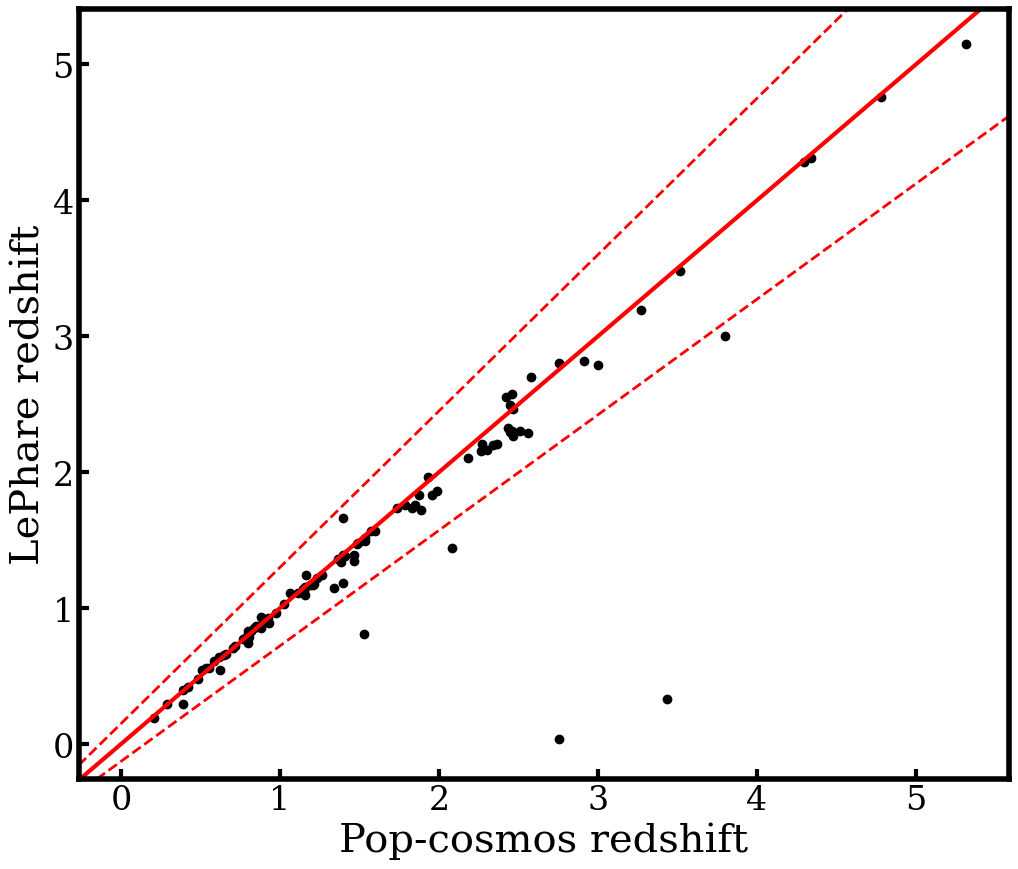

In [31]:
fig = plt.figure()
ax = fig.add_subplot()

ax.axline((0, 0), slope = 1, color = "red")
ax.axline((0.15, 0), slope = 0.85, color = "red", linestyle = "--", linewidth = 2)
ax.axline((0, 0.15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)

ax.scatter(REDSHIFTS_DeepField, PHOTOZS_DeepField_lephare, color = "black")

ax.set_ylabel("LePhare redshift")
ax.set_xlabel("Pop-cosmos redshift")

# 3: Estimate photo-zs with FlexZBoost

In [37]:
from rail.estimation.algos.flexzboost import FlexZBoostInformer, FlexZBoostEstimator

In [38]:
reference_band = 'LSST_i'

flexZBoost_parameters = dict(
    zmin              = 0.0,
    zmax              = 6.0,
    nzbins            = 601,
    trainfrac         = 0.75,
    bumpmin           = 0.02,
    bumpmax           = 0.35,
    nbump             = 20,
    sharpmin          = 0.7,
    sharpmax          = 2.1,
    nsharp            = 15,
    max_basis         = 35,
    basis_system      = "cosine",
    regression_params = {"max_depth": 8, "objective": "reg:squarederror"},
)

seed = 42

In [52]:
TRAINING_DATA_flexZBoost_specZs = PHOTOMETRY_DeepField_noisy[BANDS_WideFastDeep + ERR_BANDS_WideFastDeep]
TRAINING_DATA_flexZBoost_specZs["redshift"] = REDSHIFTS_DeepField

In [54]:
outputModelPath_FlexZBoost_specZs = f"{outputs_directory}/model_flexZBoost_specZs_{date}.pkl"


informFlexZBoost_specZs = FlexZBoostInformer.make_stage(
    model = outputModelPath_FlexZBoost_specZs,

    hdf5_groupname = "",
    redshift_col   = "redshift",
    bands          = BANDS_WideFastDeep,
    err_bands      = ERR_BANDS_WideFastDeep,
    ref_band       = "LSST_i",

    mag_limits = {band: M5_DEPTHS_DeepField[band] for band in BANDS_WideFastDeep},

    **flexZBoost_parameters
)

informFlexZBoost_specZs.inform(TRAINING_DATA_flexZBoost_specZs)
informFlexZBoost_specZs.finalize()

2026-07-07 18:04:01 [info     ] Inserting handle into data store.  input: None, FlexZBoostInformer
2026-07-07 18:04:01 [info     ] stacking some data...         
2026-07-07 18:04:01 [info     ] read in training data         
2026-07-07 18:04:01 [info     ] fit the model...              
2026-07-07 18:05:12 [info     ] finding best bump thresh...   
2026-07-07 18:08:43 [info     ] finding best sharpen parameter...
2026-07-07 18:08:46 [info     ] Retraining with full training set...
2026-07-07 18:08:46 [info     ] Best bump = 0.2631578947368421, best sharpen = 1.3
2026-07-07 18:08:46 [info     ] Inserting handle into data store.  model: /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/inprogress_model_flexZBoost_specZs_07Jul26_test2.pkl, FlexZBoostInformer


In [55]:
ESTIMATION_DATA_flexZBoost = PHOTOMETRY_WideFastDeep_noisy[BANDS_WideFastDeep + ERR_BANDS_WideFastDeep]

In [64]:
outputPath_FlexZBoost_specZs = f"{outputs_directory}/output_flexZBoost_specZs_{date}.hdf5"
estimateFlexZBoost_specZs = FlexZBoostEstimator.make_stage(
    
    model = informFlexZBoost_specZs.get_handle('model'),
    output = outputPath_FlexZBoost_specZs,
    qp_representation='flexzboost',

    hdf5_groupname = "",
    redshift_col   = "redshift",
    bands          = BANDS_WideFastDeep,
    err_bands      = ERR_BANDS_WideFastDeep,
    ref_band       = "LSST_i",

    mag_limits = {band: M5_DEPTHS_WideFastDeep[band] for band in BANDS_WideFastDeep},)

flexZBoostEstimated_specZs = estimateFlexZBoost_specZs.estimate(ESTIMATION_DATA_flexZBoost)rawPhotoZs_flexZBoost_specZs = flexZBoostEstimated_specZs.data.median()
PHOTOZS_flexZBoost_specZs = np.reshape(rawPhotoZs_flexZBoost_specZs, len(rawPhotoZs_flexZBoost_specZs))
np.save(f"{outputs_directory}/PHOTOZS_flexZBoost_specZs", PHOTOZS_flexZBoost_specZs)
    

2026-07-07 18:13:10 [info     ] Inserting handle into data store.  input: None, FlexZBoostEstimator
2026-07-07 18:13:10 [info     ] Inserting handle into data store.  model: <class 'rail.core.data.ModelHandle'> /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/model_flexZBoost_specZs_07Jul26_test2.pkl, (wd), FlexZBoostEstimator
2026-07-07 18:13:10 [info     ] Process 0 running estimator on chunk 0 - 1,000
2026-07-07 18:13:10 [info     ] Process 0 estimating PZ PDF for rows 0 - 1,000
2026-07-07 18:13:10 [info     ] Inserting handle into data store.  output: /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/inprogress_output_flexZBoost_specZs_07Jul26_test2.hdf5, FlexZBoostEstimator


In [74]:
TRAINING_DATA_flexZBoost_photoZs = PHOTOMETRY_DeepField_noisy[BANDS_WideFastDeep + ERR_BANDS_WideFastDeep]
TRAINING_DATA_flexZBoost_photoZs["redshift"] = PHOTOZS_DeepField_lephare

In [75]:
outputModelPath_FlexZBoost_photoZs = f"{outputs_directory}/model_flexZBoost_photoZs_{date}.pkl"

informFlexZBoost_photoZs = FlexZBoostInformer.make_stage(
    model = outputModelPath_FlexZBoost_photoZs,

    hdf5_groupname = "",
    redshift_col   = "redshift",
    bands          = BANDS_WideFastDeep,
    err_bands      = ERR_BANDS_WideFastDeep,
    ref_band       = "LSST_i",

    mag_limits = {band: M5_DEPTHS_DeepField[band] for band in BANDS_WideFastDeep},

    **flexZBoost_parameters
)

informFlexZBoost_photoZs.inform(TRAINING_DATA_flexZBoost_photoZs)


2026-07-07 18:16:18 [info     ] Inserting handle into data store.  input: None, FlexZBoostInformer
2026-07-07 18:16:18 [info     ] stacking some data...         
2026-07-07 18:16:18 [info     ] read in training data         
2026-07-07 18:16:18 [info     ] fit the model...              
2026-07-07 18:16:20 [info     ] finding best bump thresh...   
2026-07-07 18:16:27 [info     ] finding best sharpen parameter...
2026-07-07 18:16:30 [info     ] Retraining with full training set...
2026-07-07 18:16:30 [info     ] Best bump = 0.31526315789473686, best sharpen = 1.6
2026-07-07 18:16:30 [info     ] Inserting handle into data store.  model: /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/inprogress_model_flexZBoost_photoZs_07Jul26_test2.pkl, FlexZBoostInformer


In [77]:
outputPath_FlexZBoost_photoZs = f"{outputs_directory}/output_flexZBoost_photoZs_{date}.hdf5"

estimateFlexZBoost_photoZs = FlexZBoostEstimator.make_stage(
    
    model = informFlexZBoost_photoZs.get_handle('model'),
    output = outputPath_FlexZBoost_photoZs,
    qp_representation='flexzboost',

    hdf5_groupname = "",
    redshift_col   = "redshift",
    bands          = BANDS_WideFastDeep,
    err_bands      = ERR_BANDS_WideFastDeep,
    ref_band       = "LSST_i",

    mag_limits = {band: M5_DEPTHS_WideFastDeep[band] for band in BANDS_WideFastDeep})

flexZBoostEstimated_photoZs = estimateFlexZBoost_photoZs.estimate(ESTIMATION_DATA_flexZBoost)
rawPhotoZs_flexZBoost_photoZs = flexZBoostEstimated_photoZs.data.median()
PHOTOZS_flexZBoost_photoZs = np.reshape(rawPhotoZs_flexZBoost_photoZs, len(rawPhotoZs_flexZBoost_photoZs))
np.save(f"{outputs_directory}/PHOTOZS_flexZBoost_photoZs", PHOTOZS_flexZBoost_photoZs)
    

2026-07-07 18:18:10 [info     ] Inserting handle into data store.  input: None, FlexZBoostEstimator
2026-07-07 18:18:10 [info     ] Inserting handle into data store.  model: <class 'rail.core.data.ModelHandle'> /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/model_flexZBoost_photoZs_07Jul26_test2.pkl, (wd), FlexZBoostEstimator
2026-07-07 18:18:10 [info     ] Process 0 running estimator on chunk 0 - 1,000
2026-07-07 18:18:10 [info     ] Process 0 estimating PZ PDF for rows 0 - 1,000
2026-07-07 18:18:10 [info     ] Inserting handle into data store.  output: /pscratch/sd/s/sajkov/analysis_pipeline/runs/07Jul26_test2/inprogress_output_flexZBoost_photoZs_07Jul26_test2.hdf5, FlexZBoostEstimator


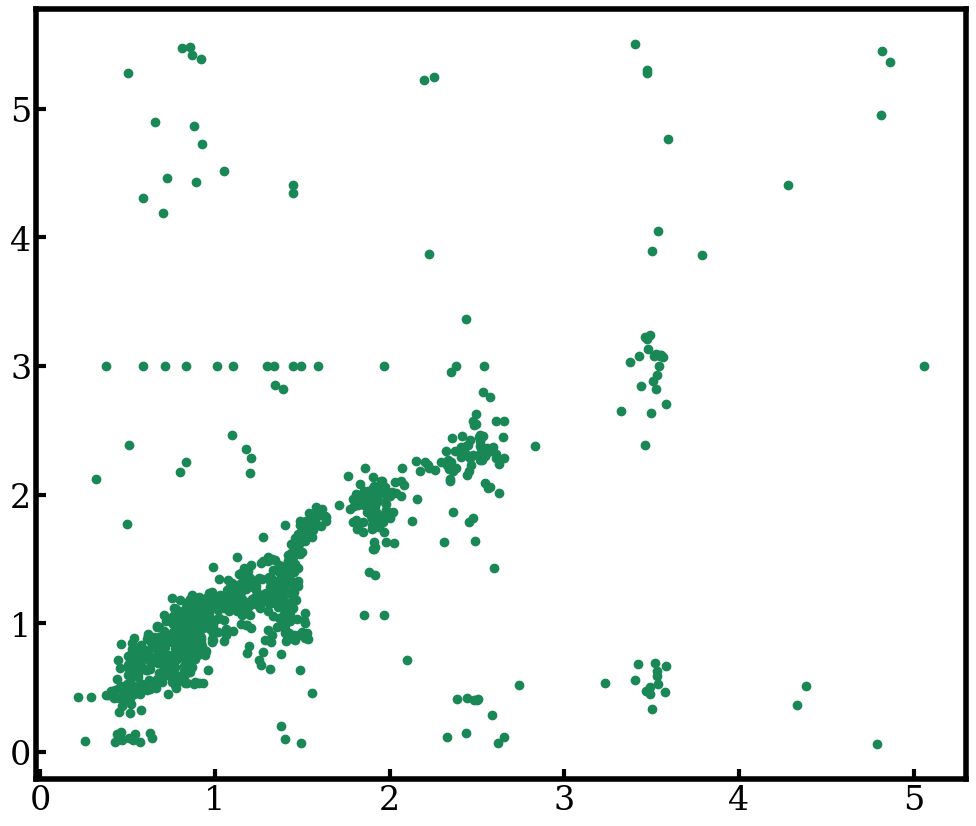

In [78]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(PHOTOZS_flexZBoost_specZs, PHOTOZS_flexZBoost_photoZs)

Text(0.5, 0, 'Photo-zs estimated\nwith photo-zs')

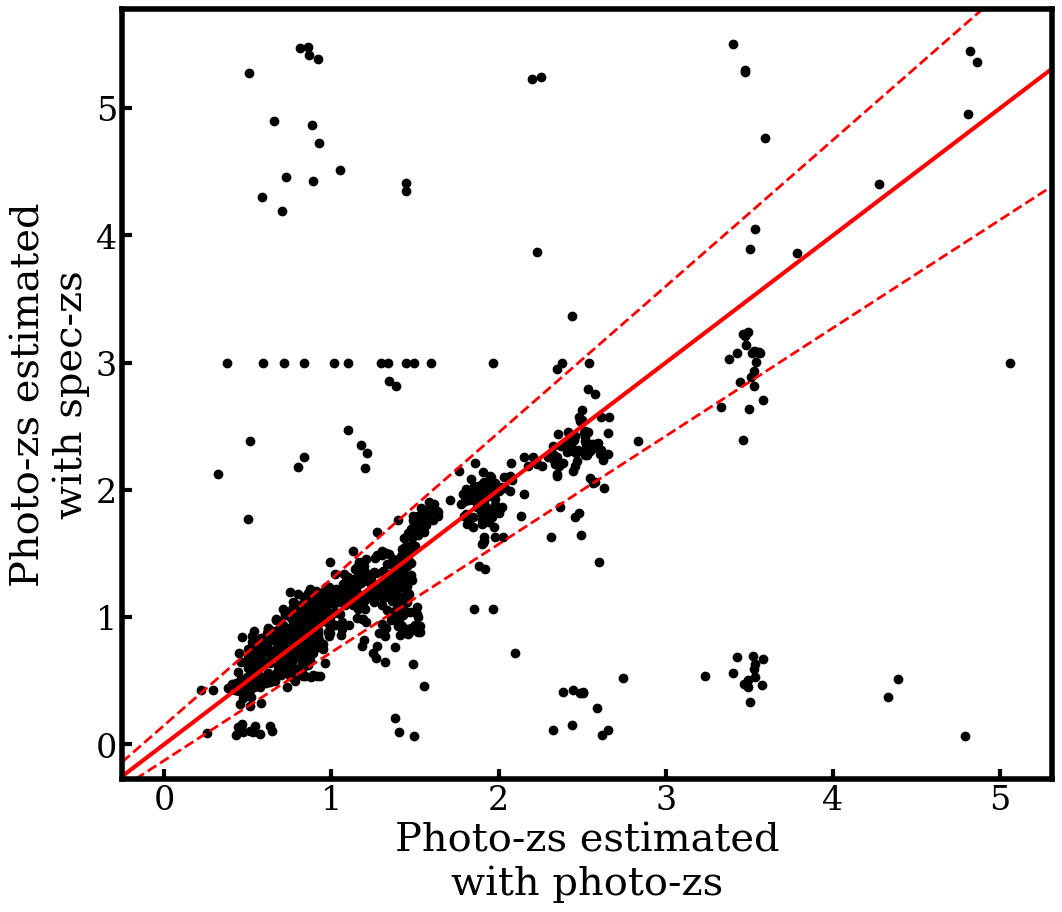

In [79]:
fig = plt.figure()
ax = fig.add_subplot()

ax.axline((0, 0), slope = 1, color = "red")
ax.axline((0.15, 0), slope = 0.85, color = "red", linestyle = "--", linewidth = 2)
ax.axline((0, 0.15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)

ax.scatter(PHOTOZS_flexZBoost_specZs, PHOTOZS_flexZBoost_photoZs, color = "black")

ax.set_ylabel("Photo-zs estimated\nwith spec-zs")
ax.set_xlabel("Photo-zs estimated\nwith photo-zs")